In [8]:
import sys
sys.path.append("..")
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import json
from datetime import datetime
from datasets import load_from_disk

from torch.utils.data import DataLoader

In [ ]:
# Загрузка модели, корневая папка проекта
from src.data import PROJECT_ROOT, load_model_and_tokenizer, RuleTakerDataset, estimate_max_length, create_minimal_pairs, compute_differential_stats, analyze_neuron_activations
from src.probing import run_probing_experiment, load_probing_results

In [10]:
sns.set_style("whitegrid")

In [11]:
CACHE_DIR = PROJECT_ROOT / "data/processed"
RESULTS_DIR = PROJECT_ROOT / "results/probing"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Эксперименты по зондированию на Pythia-1b

## Эксперимент 3: Pythia-1b + depth-0

In [12]:
# Параметры эксперимента
VARIANT = "depth-0"
MODEL_SIZE = "1b"
USE_SMALL = True
HOOK_NAME = "resid_post"
POOLING = "last"
BATCH_SIZE = 16

### Подготовка модели и данных

In [43]:
model, tokenizer = load_model_and_tokenizer(model_size=MODEL_SIZE, device="cuda")
model.eval()

Loaded pretrained model EleutherAI/pythia-1b-deduped into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-15): 16 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
    

In [14]:
# Загружаем усеченную версию датасета
cache_suffix = f"{VARIANT}_small" if USE_SMALL else VARIANT
cache_path = CACHE_DIR / f"ruletaker_{cache_suffix}"
dataset = load_from_disk(str(cache_path))

In [15]:
# если выборка до 5000 наблюдений
tmp_tokens = tokenizer(list(dataset["train"]["text"]), padding=False, truncation=False)
lengths = [len(ids) for ids in tmp_tokens['input_ids']]
max_full = max(lengths)
max_p95 = int(np.percentile(lengths, 95))
print(f"95-й перцентиль: {max_p95} токенов (при макс длине {max_full})")

95-й перцентиль: 191 токенов (при макс длине 239)


In [16]:
# max_p95 = estimate_max_length(list(dataset["train"]["text"]), tokenizer, percentile=95, sample_size=500)

In [17]:
MAX_LENGTH = max_p95

In [18]:
train_dataset = RuleTakerDataset(dataset["train"], tokenizer, max_length=MAX_LENGTH)
dev_dataset = RuleTakerDataset(dataset["dev"], tokenizer, max_length=MAX_LENGTH)

In [19]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Метод probing classifiers

In [20]:
n_layers = model.cfg.n_layers
d_model = model.cfg.d_model

In [21]:
n_layers

16

In [22]:
torch.cuda.empty_cache()

In [23]:
# Кэшируем активации
results = run_probing_experiment(
    model, train_loader, dev_loader, n_layers,
    hook_name=HOOK_NAME, pooling=POOLING
)

Probing layers: 100%|██████████| 16/16 [3:31:28<00:00, 793.05s/it]  


In [44]:
# Извлечение данных для графиков
train_accs = results["train_accs"]
dev_accs = results["dev_accs"]
train_means = [s["mean_abs"] for s in results["train_stats"]]
dev_means = [s["mean_abs"] for s in results["dev_stats"]]
train_stds = [s["std_abs"] for s in results["train_stats"]]
dev_stds = [s["std_abs"] for s in results["dev_stats"]]
train_sparsity = [s["sparsity"] for s in results["train_stats"]]
dev_sparsity = [s["sparsity"] for s in results["dev_stats"]]

In [45]:
# Визуализация результатов
best_layer = int(np.argmax(dev_accs))
best_train_acc = float(train_accs[best_layer])
best_dev_acc = float(dev_accs[best_layer])
print(f"Лучший слой: {best_layer} (0-based), Dev Accuracy: {best_dev_acc:.4f}")

Лучший слой: 11 (0-based), Dev Accuracy: 0.5680


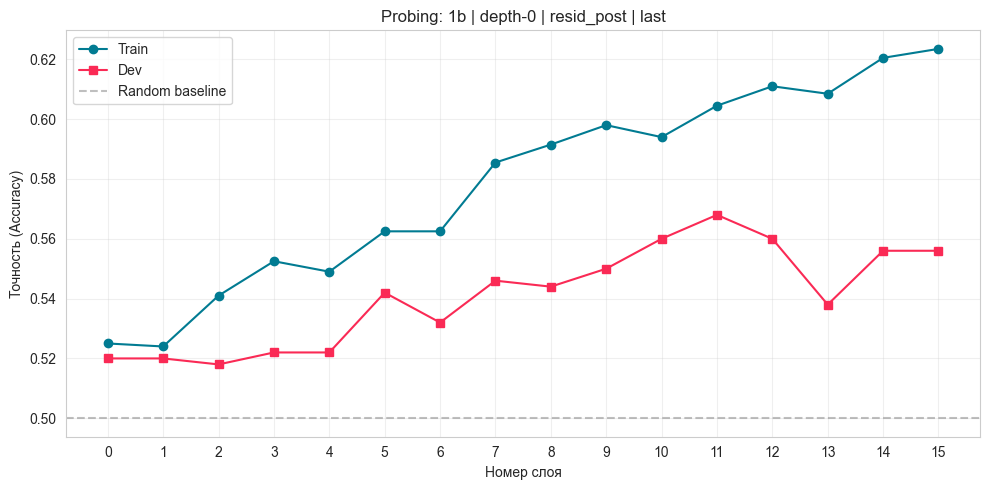

In [26]:
plt.figure(figsize=(10, 5))
x = np.arange(n_layers)
plt.plot(x, train_accs, marker="o", label="Train", color="xkcd:ocean")
plt.plot(x, dev_accs, marker="s", label="Dev", color="xkcd:red pink")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random baseline")
plt.xlabel("Номер слоя")
plt.ylabel("Точность (Accuracy)")
plt.title(f"Probing: {MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING}")
plt.xticks(x)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

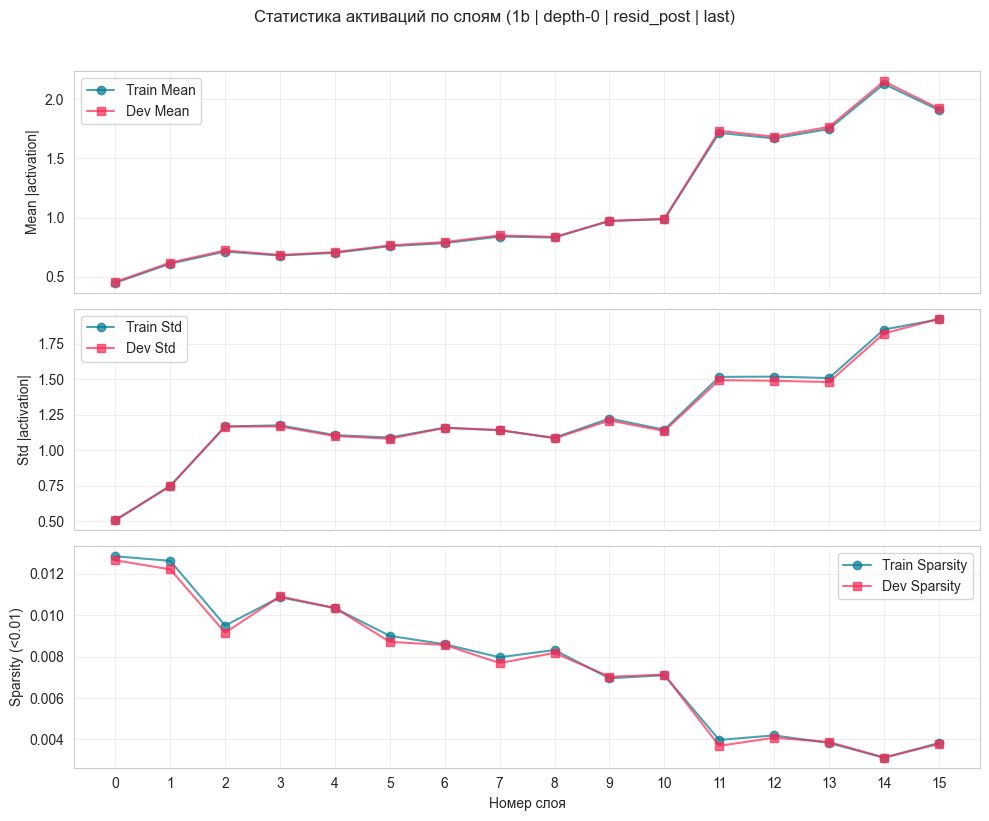

In [27]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax1.plot(x, train_means, marker="o", label="Train Mean", color="xkcd:ocean", alpha=0.7)
ax1.plot(x, dev_means, marker="s", label="Dev Mean", color="xkcd:red pink", alpha=0.7)
ax1.set_ylabel("Mean |activation|")
ax1.set_xticks(x)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(x, train_stds, marker="o", label="Train Std", color="xkcd:ocean", alpha=0.7)
ax2.plot(x, dev_stds, marker="s", label="Dev Std", color="xkcd:red pink", alpha=0.7)
ax2.set_ylabel("Std |activation|")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(x, train_sparsity, marker="o", label="Train Sparsity", color="xkcd:ocean", alpha=0.7)
ax3.plot(x, dev_sparsity, marker="s", label="Dev Sparsity", color="xkcd:red pink", alpha=0.7)
ax3.set_ylabel("Sparsity (<0.01)")
ax3.set_xlabel("Номер слоя")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle(f"Статистика активаций по слоям ({MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING})", y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# Сохранение метрик в JSON
fname = f"probe_{MODEL_SIZE}_{VARIANT}_{HOOK_NAME}_{POOLING}.json"
fpath = RESULTS_DIR / fname

In [29]:
metrics = {
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "best_layer": best_layer,
    "best_dev_acc": float(best_dev_acc),
    "train_accs": [float(a) for a in train_accs],
    "dev_accs": [float(a) for a in dev_accs]
}

# Исходные условия эксперимента
metadata = {
    "experiment_type": "probing_layer_selection",
    "timestamp": datetime.now().isoformat(),
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "batch_size": BATCH_SIZE,
    "max_length": MAX_LENGTH
}

# Основной результат
summary = {
    "best_layer": best_layer,
    "best_train_acc": best_train_acc,
    "best_dev_acc": best_dev_acc,
    "n_layers": len(results["layers"])
}

# Свод
full_data = {
    "metadata": metadata,
    "summary": summary,
    "layers": results["layers"],
    "train_accs": [float(x) for x in results["train_accs"]],
    "dev_accs": [float(x) for x in results["dev_accs"]],
    "train_stats": results["train_stats"],
    "dev_stats": results["dev_stats"]
}

with open(fpath, "w", encoding="utf-8") as f:
    json.dump(full_data, f, indent=2, ensure_ascii=False)
print(f"Результаты сохранены: {fpath}")

Результаты сохранены: C:\MyPythonProjects\mephi_diss\results\probing\probe_1b_depth-0_resid_post_last.json


### Проверка токенизации

In [31]:
# Список ключевых слов для проверки
logic_keywords = ["if", "then", "and", "or", "not", "implies", "is", "are", "all", "some", "no"]

In [32]:
# Возьмём несколько примеров из датасета (первые 3 из train)
sample_texts = list(dataset["train"]["text"])[:3]

In [33]:
for i, text in enumerate(sample_texts):
    print(f"Пример {i+1}:\n{text[:300]}...\n")  # первые 300 символов
    tokens = tokenizer.tokenize(text)
    print(f"Токены (первые 50): {tokens[:50]}\n")

    # Проверка каждого ключевого слова
    print("Наличие ключевых слов в тексте и токенах:")
    for kw in logic_keywords:
        in_text = kw in text.lower()
        # ищем токен, совпадающий с kw (без учёта регистра)
        in_tokens = any(tok.lstrip("Ġ").lower() == kw for tok in tokens)
        print(f"  '{kw}': в тексте={in_text}, в токенах={in_tokens}")
    print("-" * 80)

Пример 1:
Anne is blue. Anne is rough. Anne is young. All young people are cold. If someone is rough and nice then they are green. Rough people are young. If Anne is green then Anne is blue. If someone is rough and furry then they are blue. Cold people are rough. Anne is rough....

Токены (первые 50): ['Anne', 'Ġis', 'Ġblue', '.', 'ĠAnne', 'Ġis', 'Ġrough', '.', 'ĠAnne', 'Ġis', 'Ġyoung', '.', 'ĠAll', 'Ġyoung', 'Ġpeople', 'Ġare', 'Ġcold', '.', 'ĠIf', 'Ġsomeone', 'Ġis', 'Ġrough', 'Ġand', 'Ġnice', 'Ġthen', 'Ġthey', 'Ġare', 'Ġgreen', '.', 'ĠRough', 'Ġpeople', 'Ġare', 'Ġyoung', '.', 'ĠIf', 'ĠAnne', 'Ġis', 'Ġgreen', 'Ġthen', 'ĠAnne', 'Ġis', 'Ġblue', '.', 'ĠIf', 'Ġsomeone', 'Ġis', 'Ġrough', 'Ġand', 'Ġfur', 'ry']

Наличие ключевых слов в тексте и токенах:
  'if': в тексте=True, в токенах=True
  'then': в тексте=True, в токенах=True
  'and': в тексте=True, в токенах=True
  'or': в тексте=False, в токенах=False
  'not': в тексте=False, в токенах=False
  'implies': в тексте=False, в токенах=False


In [34]:
# Токенизация самих ключевых слов как отдельных строк
for kw in logic_keywords:
    tokens_kw = tokenizer.tokenize(kw)
    is_single = len(tokens_kw) == 1
    print(f"'{kw}' -> {tokens_kw} (цельный токен: {is_single})")

'if' -> ['if'] (цельный токен: True)
'then' -> ['then'] (цельный токен: True)
'and' -> ['and'] (цельный токен: True)
'or' -> ['or'] (цельный токен: True)
'not' -> ['not'] (цельный токен: True)
'implies' -> ['impl', 'ies'] (цельный токен: False)
'is' -> ['is'] (цельный токен: True)
'are' -> ['are'] (цельный токен: True)
'all' -> ['all'] (цельный токен: True)
'some' -> ['some'] (цельный токен: True)
'no' -> ['no'] (цельный токен: True)


### Разностный анализ активаций

In [35]:
data = load_probing_results(MODEL_SIZE, VARIANT, HOOK_NAME, POOLING)

In [ ]:
data

In [36]:
DIFF_LAYER = data["summary"]["best_layer"]

In [37]:
pairs = create_minimal_pairs(variant=VARIANT, n_pairs=30)

In [46]:
diff_stats = compute_differential_stats(
    model, tokenizer, pairs,
    layer_idx=DIFF_LAYER,
    hook_name=HOOK_NAME,
    pooling=POOLING,
    max_length=data["metadata"]["max_length"]   # или из MAX_LENGTH
)

In [47]:
print(f"Средняя абсолютная разница активаций: {diff_stats['mean_abs_diff']:.4f}")
print(f"Стандартное отклонение разницы: {diff_stats['std_diff']:.4f}")

Средняя абсолютная разница активаций: 0.0557
Стандартное отклонение разницы: 0.2263


In [48]:
neuron_sens = diff_stats['neuron_sensitivity']
top_neurons = np.argsort(neuron_sens)[-100:][::-1]
print("Топ-100 нейронов с наибольшей средней разницей:")
for i, n in enumerate(top_neurons):
    print(f"  Нейрон {n}: {neuron_sens[n]:.4f}")

Топ-100 нейронов с наибольшей средней разницей:
  Нейрон 232: 0.6055
  Нейрон 1467: 0.4675
  Нейрон 1559: 0.3845
  Нейрон 1668: 0.3464
  Нейрон 1462: 0.2426
  Нейрон 1429: 0.2209
  Нейрон 290: 0.1941
  Нейрон 1638: 0.1893
  Нейрон 814: 0.1685
  Нейрон 1729: 0.1519
  Нейрон 1282: 0.1503
  Нейрон 1736: 0.1448
  Нейрон 445: 0.1436
  Нейрон 1901: 0.1394
  Нейрон 1630: 0.1393
  Нейрон 313: 0.1361
  Нейрон 1806: 0.1353
  Нейрон 448: 0.1332
  Нейрон 344: 0.1316
  Нейрон 810: 0.1310
  Нейрон 782: 0.1305
  Нейрон 1224: 0.1294
  Нейрон 1164: 0.1292
  Нейрон 1643: 0.1272
  Нейрон 646: 0.1261
  Нейрон 628: 0.1251
  Нейрон 1625: 0.1247
  Нейрон 1328: 0.1235
  Нейрон 534: 0.1234
  Нейрон 158: 0.1230
  Нейрон 325: 0.1223
  Нейрон 1430: 0.1218
  Нейрон 1498: 0.1216
  Нейрон 114: 0.1215
  Нейрон 1933: 0.1212
  Нейрон 990: 0.1212
  Нейрон 35: 0.1201
  Нейрон 1982: 0.1201
  Нейрон 1172: 0.1191
  Нейрон 281: 0.1189
  Нейрон 1688: 0.1187
  Нейрон 396: 0.1183
  Нейрон 1358: 0.1181
  Нейрон 63: 0.1180
  Нейр

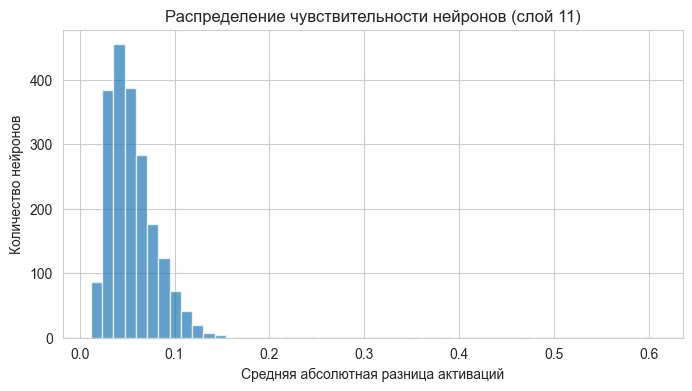

In [49]:
# Гистограмма чувствительности нейронов
plt.figure(figsize=(8,4))
plt.hist(neuron_sens, bins=50, alpha=0.7)
plt.xlabel("Средняя абсолютная разница активаций")
plt.ylabel("Количество нейронов")
plt.title(f"Распределение чувствительности нейронов (слой {DIFF_LAYER})")
plt.grid(True)
plt.show()

In [50]:
# Добавляем результаты разностного анализа в файл json с результатами пробинга
diff_stats["neuron_sensitivity"] = diff_stats["neuron_sensitivity"].tolist()
data["diff_stats"] = diff_stats
with open(fpath, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"Результаты разностного анализа добавлены в {fpath}")

Результаты разностного анализа добавлены в C:\MyPythonProjects\mephi_diss\results\probing\probe_1b_depth-0_resid_post_last.json


In [52]:
top_texts, top_tokens = analyze_neuron_activations(
    model, tokenizer,
    layer_idx=14, neuron_idx=232,
    texts=list(dataset["train"]["text"])[:200],
    top_k_examples=10,
    top_k_tokens=30
)

In [53]:
print("Топ-10 примеров для нейрона 232:")
for text, act in top_texts:
    print(f"  [{act:.3f}] {text}")

Топ-10 примеров для нейрона 232:
  [19.719] Dave is nice. Fiona is nice. Fiona is white. All rough things are red. Cold, white things are young. Dave is not nice.
  [18.750] Anne is quiet. Bob is young. Fiona is white. Harry is young. If someone is not kind then they are cold. Harry is young.
  [18.703] Dave is nice. Fiona is nice. Fiona is white. All rough things are red. Cold, white things are young. Dave is not red.
  [18.453] Dave is nice. Fiona is nice. Fiona is white. All rough things are red. Cold, white things are young. Dave is rough.
  [18.359] Dave is cold. Dave is furry. Dave is nice. Dave is quiet. Dave is red. Dave is round. Dave is white. If something is furry and red then it is round. All nice, cold things are quiet. Dave is not nice.
  [18.156] Dave is nice. Fiona is nice. Fiona is white. All rough things are red. Cold, white things are young. Fiona is nice.
  [17.766] Anne is quiet. Bob is young. Fiona is white. Harry is young. If someone is not kind then they are col

In [54]:
print("Топ-30 токенов для нейрона 232:")
for token, score in top_tokens:
    print(f"{token.strip()}: {score:+.3f}")

Топ-30 токенов для нейрона 232:
someone: +17.438
Dave: +16.641
Young: +16.094
.: +16.047
bear: +15.992
lion: +15.992
urry: +15.859
Erin: +15.758
tiger: +15.680
Smart: +15.484
Charlie: +15.297
Anne: +15.281
rabbit: +15.281
Bob: +15.258
cat: +15.219
eagle: +14.898
mouse: +14.898
people: +14.859
like: +14.656
dog: +14.523
rel: +14.422
quiet: +14.312
young: +14.289
White: +14.094
Anne: +14.078
something: +14.078
cold: +14.062
blue: +13.969
they: +13.883
big: +13.867
